# 02 — Lexical baseline, deep dive

`eda_report.md` (Phase 3) reports one mean readability score, one MTLD, one
top-15 bigram list per PM. This notebook goes past the single-number summary:
full distributions (not just means), a direct visual justification for why
MTLD was chosen over TTR, and the full n-gram / TF-IDF tables the report only
shows a truncated view of.

All statistics are computed with the same functions `eda.py` uses
(`src/hansard_pm_nlp/lexical.py`) — nothing here is redefined.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from hansard_pm_nlp.lexical import (
    flesch_kincaid_grade,
    mean_words_per_sentence,
    mtld,
    tfidf_top_terms_by_group,
    tokenize_words,
    top_ngrams,
    type_token_ratio,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

df = pd.read_parquet(str(PROJECT_ROOT / "data" / "processed" / "pm_contributions_clean.parquet"))
df["sitting_date"] = pd.to_datetime(df["sitting_date"])
PM_ORDER = df["pm_name"].value_counts().index.tolist()
df.shape


(10673, 18)

## 1. Per-contribution readability and sentence length — full distributions

`eda.py` averages these per PM. Averaging hides shape: a PM who is usually
simple but occasionally delivers one very technical statement looks
identical, on the mean alone, to a PM who is consistently mid-complexity.


In [2]:
sample = df.sample(n=min(4000, len(df)), random_state=42).copy()
sample["fk_grade"] = sample["contribution_text"].map(flesch_kincaid_grade)
sample["words_per_sentence"] = sample["contribution_text"].map(mean_words_per_sentence)
sample = sample.replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["fk_grade", "words_per_sentence"])
len(sample)


4000

Sampled to 4,000 rather than scored on all 10,673 — this notebook is about
shape, not another decimal of precision on the mean, and `textstat` calls are
slow enough that the full corpus isn't worth the wait for that purpose. Phase
3's official summary already used the full corpus.


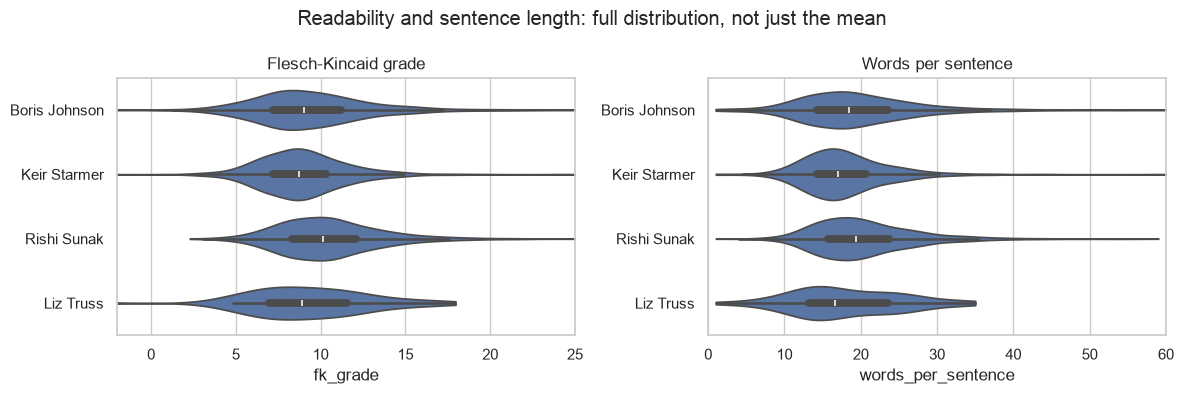

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.violinplot(data=sample, x="fk_grade", y="pm_name", order=PM_ORDER, ax=axes[0], cut=0)
axes[0].set_xlim(-2, 25)
axes[0].set_title("Flesch-Kincaid grade")
axes[0].set_ylabel("")
sns.violinplot(data=sample, x="words_per_sentence", y="pm_name", order=PM_ORDER, ax=axes[1], cut=0)
axes[1].set_xlim(0, 60)
axes[1].set_title("Words per sentence")
axes[1].set_ylabel("")
fig.suptitle("Readability and sentence length: full distribution, not just the mean")
fig.tight_layout()


The means in `eda_report.md` (FK grade 8.96-10.74 across PMs) sit inside a
much wider spread for every PM — the violins overlap heavily. That's the
honest picture the single-number summary can't show: readability differences
between PMs are real on average but small relative to each PM's own
sitting-to-sitting variation. Useful context before over-reading the
stylometric radar's readability axis as a sharp PM fingerprint.


## 2. Why MTLD instead of TTR: the length-bias problem, shown directly

`lexical.py`'s docstring asserts TTR is "biased by corpus size" without
plotting it. Demonstrating it: TTR computed on contributions of increasing
length should drop mechanically as length grows, independent of any real
change in vocabulary richness.


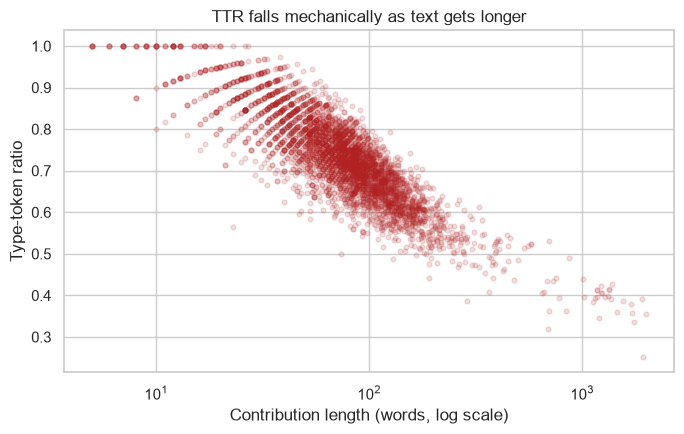

In [4]:
sample["word_count"] = sample["contribution_text"].map(lambda t: len(tokenize_words(t)))
sample["ttr"] = sample["contribution_text"].map(lambda t: type_token_ratio(tokenize_words(t)))
long_enough = sample[sample["word_count"] >= 5]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(long_enough["word_count"], long_enough["ttr"], alpha=0.15, s=12, color="firebrick")
ax.set_xscale("log")
ax.set_xlabel("Contribution length (words, log scale)")
ax.set_ylabel("Type-token ratio")
ax.set_title("TTR falls mechanically as text gets longer")
fig.tight_layout()


The downward curve is length, not style. This is precisely why per-PM TTR in
`eda_report.md` (0.026 for Johnson's 520k-word corpus vs. 0.166 for Truss's
8.8k-word corpus) is not a usable comparison — Truss's TTR is high mostly
*because* her corpus is tiny, not because her vocabulary is richer. MTLD
(76.8 vs. 76.4) shows the two are actually close once length is corrected
for — the metric switch in the dashboard radar is justified by this curve,
not just asserted.


## 3. Full n-gram tables (bigrams and trigrams)

In [5]:
def ngram_table(pm: str, n: int, top_k: int = 20) -> pd.DataFrame:
    text = " ".join(df.loc[df["pm_name"] == pm, "contribution_text"])
    tokens = tokenize_words(text)
    grams = top_ngrams(tokens, n=n, top_k=top_k)
    return pd.DataFrame(grams, columns=["ngram", "count"])

for pm in PM_ORDER:
    print(f"\n=== {pm}: top trigrams ===")
    display(ngram_table(pm, n=3, top_k=10))



=== Boris Johnson: top trigrams ===


,ngram,count
0,my hon friend,1459
1,the right hon,1439
2,my right hon,772
3,right hon friend,729
4,hon and learned,701
5,right hon and,699
6,the hon gentleman,645
7,right hon gentleman,628
8,and learned gentleman,596
9,the people of,557



=== Keir Starmer: top trigrams ===


,ngram,count
0,my hon friend,836
1,the right hon,593
2,that is why,353
3,leader of the,322
4,in relation to,321
5,the leader of,317
6,of the opposition,314
7,hon friend for,286
8,right hon gentleman,285
9,i thank my,280



=== Rishi Sunak: top trigrams ===


,ngram,count
0,my hon friend,711
1,the right hon,417
2,my right hon,337
3,hon and learned,332
4,right hon and,328
5,right hon friend,307
6,and learned gentleman,301
7,that is why,298
8,the hon gentleman,252
9,will continue to,224



=== Liz Truss: top trigrams ===


,ngram,count
0,make sure that,26
1,to make sure,23
2,the right hon,23
3,my hon friend,23
4,my right hon,20
5,right hon friend,19
6,right hon and,16
7,hon and learned,16
8,we need to,16
9,and learned gentleman,15


`eda_report.md` only lists bigrams. Trigrams surface longer stock phrases
("i can tell", "we are going", "as a result") that are more distinctly
attributable to a speaker's habitual phrasing than two-word combinations,
most of which are just English grammar (`of the`, `in the`) shared by
everyone.


## 4. Full TF-IDF distinctive-term tables

In [6]:
per_pm_text = {pm: " ".join(g["contribution_text"]) for pm, g in df.groupby("pm_name")}
tfidf_terms = tfidf_top_terms_by_group(per_pm_text, top_k=25)

for pm in PM_ORDER:
    print(f"\n=== {pm}: top 25 distinctive TF-IDF terms ===")
    print(", ".join(f"{t} ({s:.3f})" for t, s in tfidf_terms[pm]))



=== Boris Johnson: top 25 distinctive TF-IDF terms ===
hon (0.485), right (0.325), people (0.268), country (0.256), friend (0.211), gentleman (0.175), think (0.155), house (0.150), government (0.141), way (0.110), support (0.109), uk (0.097), want (0.095), thank (0.093), say (0.086), going (0.081), said (0.080), course (0.079), know (0.079), doing (0.075), just (0.075), make (0.074), work (0.072), world (0.071), point (0.069)

=== Keir Starmer: top 25 distinctive TF-IDF terms ===
hon (0.426), right (0.241), friend (0.178), house (0.169), important (0.167), government (0.160), thank (0.141), people (0.140), work (0.134), country (0.132), gentleman (0.109), years (0.104), support (0.103), security (0.102), issue (0.100), need (0.096), know (0.096), defence (0.093), make (0.091), member (0.091), working (0.089), opposition (0.087), did (0.085), clear (0.084), want (0.082)

=== Rishi Sunak: top 25 distinctive TF-IDF terms ===
hon (0.452), right (0.361), friend (0.242), people (0.223), sup

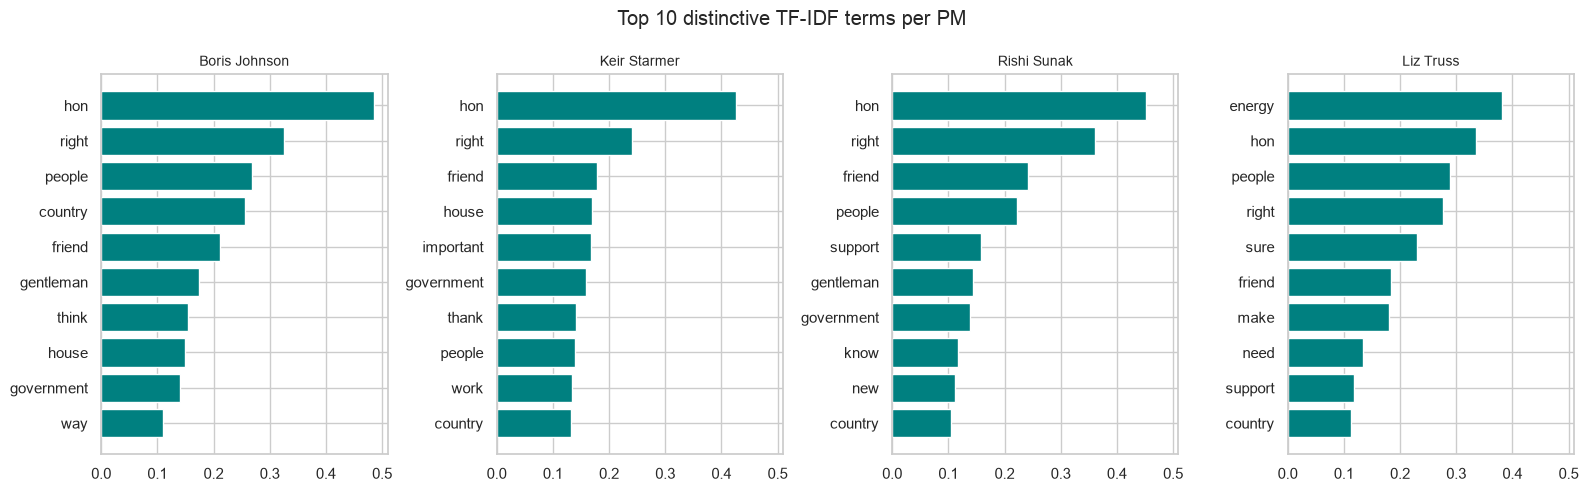

In [7]:
fig, axes = plt.subplots(1, len(PM_ORDER), figsize=(4 * len(PM_ORDER), 5), sharex=True)
for ax, pm in zip(axes, PM_ORDER, strict=True):
    top10 = tfidf_terms[pm][:10][::-1]
    terms, scores = zip(*top10, strict=True)
    ax.barh(terms, scores, color="teal")
    ax.set_title(pm, fontsize=10)
fig.suptitle("Top 10 distinctive TF-IDF terms per PM")
fig.tight_layout()


**Takeaways**

- Readability differences between PMs are real on average but small next to
  each PM's own variation sitting-to-sitting — a caveat worth carrying into
  how the stylometric radar chart is read.
- The TTR-vs-length scatter is direct visual evidence for a design decision
  (MTLD over TTR) that was previously only asserted in a docstring.
- TF-IDF terms are a far more legible, human-readable complement to the
  classifier's function-word feature importances (Phase 6) — this table is
  the natural next chart to surface in the dashboard itself (see the
  standing recommendations for the Topics/Overview tabs).
